In [1]:
from google.colab import files
uploaded = files.upload()


Saving traffic.csv to traffic.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('traffic.csv')

# Fix date
df['date'] = pd.to_datetime(df['date'])
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Day'] = df['date'].dt.day_name()

print(" Data loaded!")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

 Data loaded!
Total rows: 226278
Columns: ['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid', 'Month', 'Year', 'Day']
Date range: 2021-08-19 00:00:00 to 2021-08-25 00:00:00


In [4]:
total_sessions = len(df)
total_users = df['linkid'].nunique()
total_countries = df['country'].nunique()
total_cities = df['city'].nunique()
total_artists = df['artist'].nunique()

print("========== KEY KPIs ==========")
print(f"  Total Clicks/Sessions:  {total_sessions:,}")
print(f" Unique Users:            {total_users:,}")
print(f" Countries Reached:       {total_countries}")
print(f"  Cities Reached:          {total_cities}")
print(f" Unique Artists:          {total_artists}")

========== KEY KPIs ==========
  Total Clicks/Sessions:  226,278
 Unique Users:            3,839
 Countries Reached:       211
  Cities Reached:          11993
 Unique Artists:          2419


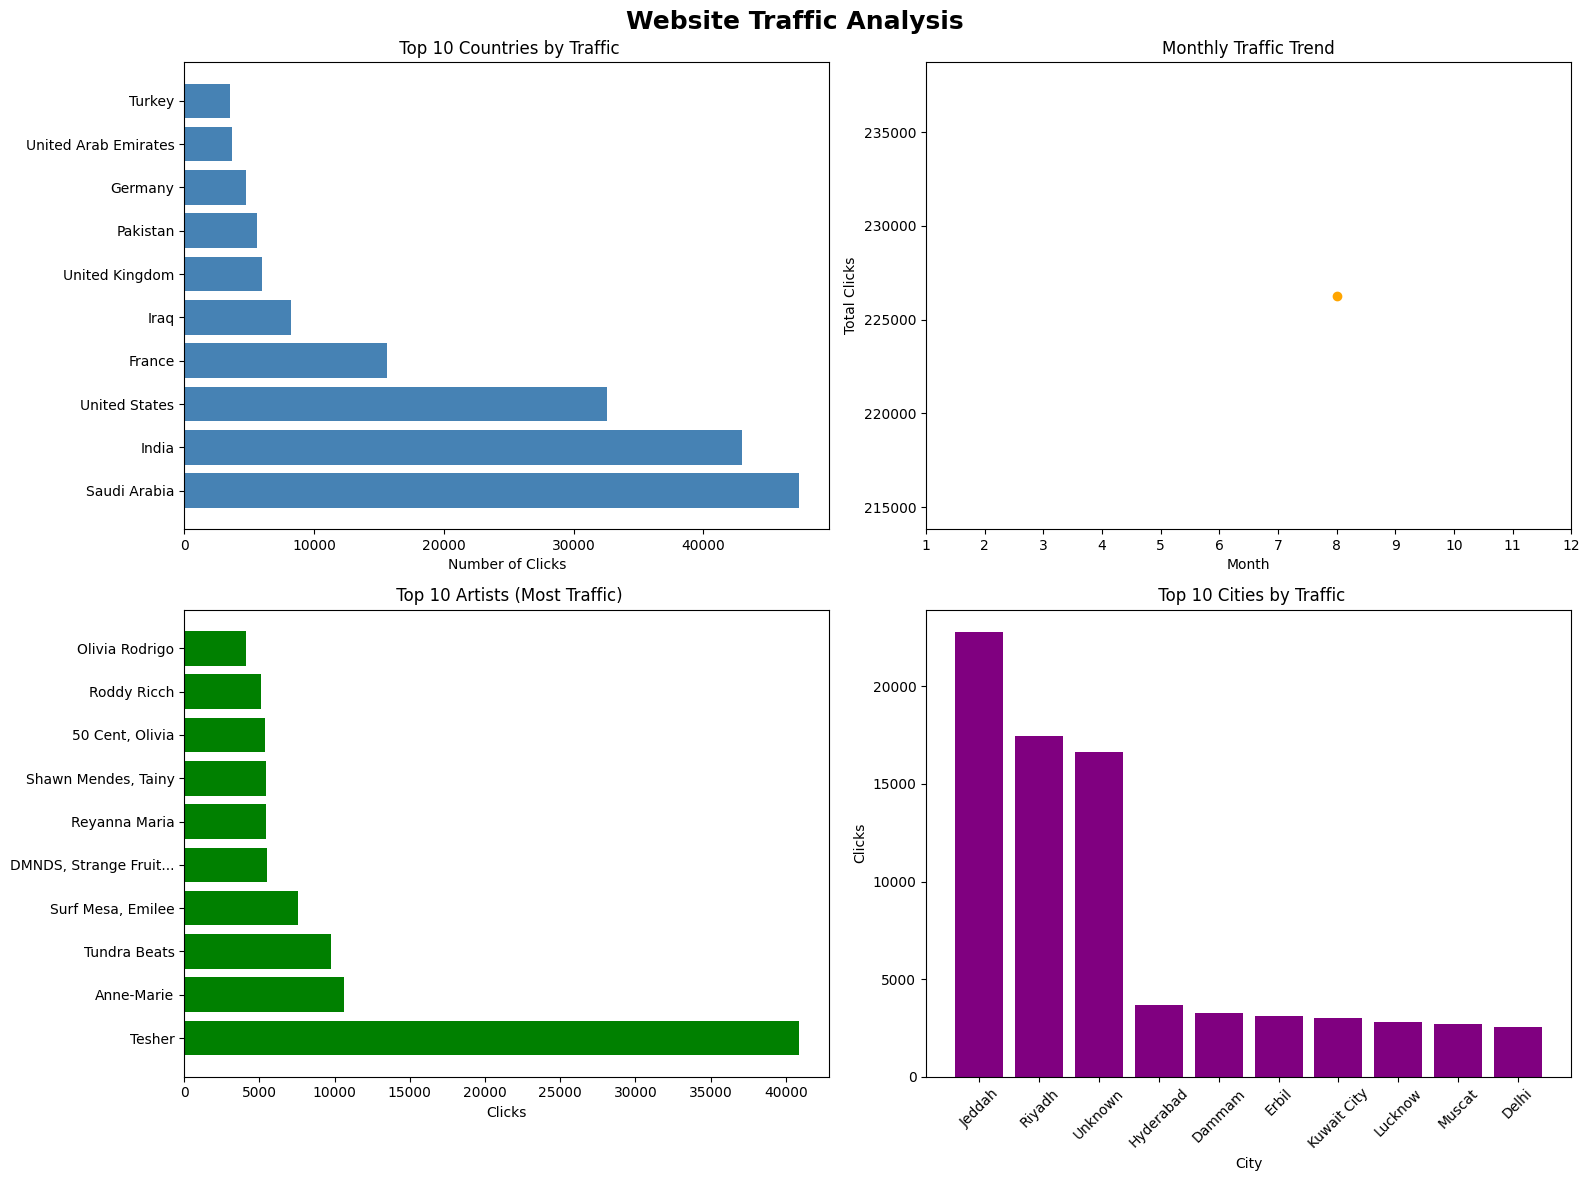

 Charts saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Website Traffic Analysis', fontsize=18, fontweight='bold')

# Chart 1: Top 10 Countries by Traffic
top_countries = df['country'].value_counts().nlargest(10)
axes[0,0].barh(top_countries.index, top_countries.values, color='steelblue')
axes[0,0].set_title(' Top 10 Countries by Traffic')
axes[0,0].set_xlabel('Number of Clicks')

# Chart 2: Monthly Traffic Trend
monthly = df.groupby('Month').size()
axes[0,1].plot(monthly.index, monthly.values, marker='o', color='orange', linewidth=2)
axes[0,1].set_title('Monthly Traffic Trend')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Clicks')
axes[0,1].set_xticks(range(1,13))

# Chart 3: Top 10 Artists (Entry Pages)
top_artists = df['artist'].value_counts().nlargest(10)
short_names = [name[:20]+'...' if len(name)>20 else name for name in top_artists.index]
axes[1,0].barh(short_names, top_artists.values, color='green')
axes[1,0].set_title(' Top 10 Artists (Most Traffic)')
axes[1,0].set_xlabel('Clicks')

# Chart 4: Top 10 Cities
top_cities = df['city'].value_counts().nlargest(10)
axes[1,1].bar(top_cities.index, top_cities.values, color='purple')
axes[1,1].set_title(' Top 10 Cities by Traffic')
axes[1,1].set_xlabel('City')
axes[1,1].set_ylabel('Clicks')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('traffic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Charts saved!")

In [6]:
print(" TOP 10 MOST VISITED TRACKS:")
print(df['track'].value_counts().nlargest(10).to_string())

print("\n TOP 10 COUNTRIES:")
print(df['country'].value_counts().nlargest(10).to_string())

print("\n TRAFFIC BY DAY OF WEEK:")
print(df['Day'].value_counts().to_string())

print("\n TRAFFIC BY YEAR:")
print(df['Year'].value_counts().sort_index().to_string())

 TOP 10 MOST VISITED TRACKS:
track
Jalebi Baby                              40841
Beautiful                                10658
Beautiful Day                             9751
ily (i love you baby) (feat. Emilee)      7533
So Pretty                                 5664
Calabria (feat. Lujavo & Nito-Onna)       5512
Summer of Love (Shawn Mendes & Tainy)     5409
Candy Shop                                5375
Late At Night                             5036
Build a Bitch                             3879

 TOP 10 COUNTRIES:
country
Saudi Arabia            47334
India                   42992
United States           32558
France                  15661
Iraq                     8260
United Kingdom           5970
Pakistan                 5644
Germany                  4794
United Arab Emirates     3702
Turkey                   3514

 TRAFFIC BY DAY OF WEEK:
Day
Thursday     35361
Friday       34112
Saturday     34083
Sunday       32633
Wednesday    30447
Tuesday      29834
Monday       29808

 TR

1.  India & Saudi Arabia mein targeted campaigns chalaao — highest traffic wahan se hai
2.  Low traffic months mein special promotions do — engagement badhega  
3.  Top artists ke saath collaborations karo — unka traffic sabse zyada hai
4.  Top cities mein local language content banao — conversion badhegi
5.  Mobile-friendly pages banao — streaming users mostly mobile pe hote hain